# **Main Notebook**

## Setup and Data Collection

#### Imports and Plot Setup

In [22]:
# Imports
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import time
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

#### Github Authorization

In [23]:
from config import GITHUB_TOKEN

headers = {
    'Authorization': f'token {GITHUB_TOKEN}',
    'Accept': 'application/vnd.github.v3+json'
}

BASE_URL = "https://api.github.com"

#### Check for secrets leak

In [24]:
import re

def check_for_secrets(notebook_path):
    """Check if notebook contains potential secrets"""
    with open(notebook_path, 'r') as f:
        content = f.read()
    
    patterns = [
        r'ghp_[a-zA-Z0-9]{36}',  # GitHub personal access token
        r'github_pat_[a-zA-Z0-9]{22}_[a-zA-Z0-9]{59}',  # GitHub fine-grained token
        r'GITHUB_TOKEN\s*=\s*["\'][^"\']+["\']',  # Hardcoded token assignment
    ]
    
    for pattern in patterns:
        if re.search(pattern, content):
            print("WARNING: Potential secret found!")
            return False
    
    print("No obvious secrets detected")
    return True

check_for_secrets('notebook.ipynb')

No obvious secrets detected


True

#### Function to check Rate limits

In [25]:
def check_rate_limit():
    """Check remaining API calls"""
    response = requests.get(f"{BASE_URL}/rate_limit", headers=headers)
    data = response.json()
    return data['rate']['remaining'], data['rate']['reset']

check_rate_limit()

(3971, 1773416861)

#### Data Collection Functions

In [26]:
def search_repositories(query, sort='stars', order='desc', per_page=100, max_pages=10):
    """
    Search GitHub repositories
    
    Parameters:
    - query: search query (e.g., 'stars:>1000', 'language:python')
    - sort: 'stars', 'forks', 'updated'
    - order: 'asc' or 'desc'
    """
    repos = []
    
    for page in range(1, max_pages + 1):
        url = f"{BASE_URL}/search/repositories"
        params = {
            'q': query,
            'sort': sort,
            'order': order,
            'per_page': per_page,
            'page': page
        }
        
        response = requests.get(url, headers=headers, params=params)
        
        if response.status_code == 200:
            data = response.json()
            repos.extend(data['items'])
            
            # Check if there are more pages
            if len(data['items']) < per_page:
                break
                
            # Respect rate limiting
            time.sleep(1)
        else:
            print(f"Error: {response.status_code}")
            break
    
    return repos



#################################################################

def get_repo_languages(owner, repo_name):
    """Get languages used in a repository"""
    url = f"{BASE_URL}/repos/{owner}/{repo_name}/languages"
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        return response.json()
    return {}



#################################################################

def get_repo_topics(owner, repo_name):
    """Get topics/tags for a repository"""
    url = f"{BASE_URL}/repos/{owner}/{repo_name}/topics"
    headers_topics = headers.copy()
    headers_topics['Accept'] = 'application/vnd.github.mercy-preview+json'
    
    response = requests.get(url, headers=headers_topics)
    
    if response.status_code == 200:
        return response.json().get('names', [])
    return []


################################################################

print("Functions defined successfully!")

Functions defined successfully!


#### Collect Repository Data

In [27]:
print("Collecting top repositories...")

# Collect top starred repos
top_repos = search_repositories(
    query='stars:>5000',  # Adjust threshold as needed
    sort='stars',
    per_page=100,
    max_pages=10  # This gives you up to 1000 repos
)

print(f"Collected {len(top_repos)} repositories")

# Check rate limit
remaining, reset_time = check_rate_limit()
print(f"Rate limit remaining: {remaining}")

KeyboardInterrupt: 

#### Converting to dataframe and extracting info

In [ ]:
df = pd.DataFrame(top_repos)

# Extract key fields
df_clean = pd.DataFrame({
    'name': df['name'],
    'full_name': df['full_name'],
    'owner': df['owner'].apply(lambda x: x['login']),
    'description': df['description'],
    'language': df['language'],
    'stars': df['stargazers_count'],
    'forks': df['forks_count'],
    'watchers': df['watchers_count'],
    'size': df['size'],
    'created_at': pd.to_datetime(df['created_at']),
    'updated_at': pd.to_datetime(df['updated_at']),
    'pushed_at': pd.to_datetime(df['pushed_at']),
    'open_issues': df['open_issues_count'],
    'license': df['license'].apply(lambda x: x['name'] if x else 'No License'),
    'topics': df.get('topics', [[] for _ in range(len(df))]),
    'has_wiki': df['has_wiki'],
    'has_pages': df['has_pages'],
    'archived': df['archived']
})

# Calculate repo age
df_clean['age_days'] = (pd.Timestamp.now(tz='UTC') - df_clean['created_at']).dt.days

# Calculate stars per day (popularity velocity)
df_clean['stars_per_day'] = df_clean['stars'] / (df_clean['age_days'] + 1)

# Save raw data
df_clean.to_csv('github_repos_raw.csv', index=False)
print("Data saved!")

df_clean.head()

Data saved!


,name,full_name,owner,description,language,stars,forks,watchers,size,created_at,updated_at,pushed_at,open_issues,license,topics,has_wiki,has_pages,archived,age_days,stars_per_day
0,build-your-own-x,codecrafters-io/build-your-own-x,codecrafters-io,Master programming by recreating your favorite...,Markdown,474726,44515,474726,1201,2018-05-09 12:03:18+00:00,2026-03-13 15:02:07+00:00,2026-02-21 09:34:54+00:00,442,No License,"[awesome-list, free, programming, tutorial-cod...",False,False,False,2865,165.640614
1,awesome,sindresorhus/awesome,sindresorhus,😎 Awesome lists about all kinds of interesting...,NaN,445182,33522,445182,1534,2014-07-11 13:42:37+00:00,2026-03-13 15:01:03+00:00,2026-03-09 07:59:57+00:00,78,Creative Commons Zero v1.0 Universal,"[awesome, awesome-list, lists, resources, unic...",False,True,False,4263,104.404784
2,freeCodeCamp,freeCodeCamp/freeCodeCamp,freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,TypeScript,438078,43593,438078,554744,2014-12-24 17:49:19+00:00,2026-03-13 14:59:55+00:00,2026-03-13 14:27:08+00:00,260,"BSD 3-Clause ""New"" or ""Revised"" License","[careers, certification, community, curriculum...",False,False,False,4096,106.926532
3,public-apis,public-apis/public-apis,public-apis,A collective list of free APIs,Python,409004,44187,409004,5012,2016-03-20 23:49:42+00:00,2026-03-13 15:02:46+00:00,2026-02-19 15:14:35+00:00,972,MIT License,"[api, apis, dataset, development, free, list, ...",False,False,False,3644,112.209602
4,free-programming-books,EbookFoundation/free-programming-books,EbookFoundation,:books: Freely available programming books,Python,383945,66007,383945,21056,2013-10-11 06:50:37+00:00,2026-03-13 15:01:39+00:00,2026-03-12 00:48:42+00:00,69,Creative Commons Attribution 4.0 International,"[books, education, hacktoberfest, list, resource]",False,True,False,4536,84.625303


#### Language Details

In [29]:
print("Fetching detailed language information...")

language_details = []
repo_topics = []

for idx, row in df_clean.iterrows():
    if idx % 50 == 0:
        print(f"Processing repo {idx}/{len(df_clean)}")
    
    # Get languages
    langs = get_repo_languages(row['owner'], row['name'])
    language_details.append(langs)
    
    # Get topics
    topics = get_repo_topics(row['owner'], row['name'])
    repo_topics.append(topics)
    
    time.sleep(0.5)  # Rate limiting

df_clean['all_languages'] = language_details
df_clean['topics'] = repo_topics


Fetching detailed language information...
Processing repo 0/1000
Processing repo 50/1000
Processing repo 100/1000
Processing repo 150/1000
Processing repo 200/1000
Processing repo 250/1000
Processing repo 300/1000
Processing repo 350/1000
Processing repo 400/1000
Processing repo 450/1000
Processing repo 500/1000
Processing repo 550/1000
Processing repo 600/1000
Processing repo 650/1000
Processing repo 700/1000
Processing repo 750/1000
Processing repo 800/1000
Processing repo 850/1000
Processing repo 900/1000
Processing repo 950/1000


## Data Processing and Classification

#### Process Language Data

In [30]:
def calculate_language_percentages(lang_dict):
    """Convert language bytes to percentages"""
    if not lang_dict:
        return {}
    total = sum(lang_dict.values())
    return {lang: (bytes/total)*100 for lang, bytes in lang_dict.items()}

df_clean['language_percentages'] = df_clean['all_languages'].apply(calculate_language_percentages)

# Get primary language (highest percentage)
df_clean['primary_language'] = df_clean['language_percentages'].apply(
    lambda x: max(x.keys(), key=lambda k: x[k]) if x else 'Unknown'
)

#### Domain Classification Based on Topics and Description

In [31]:
def classify_repo_domain(row):
    """Classify repository into domains based on topics and description"""
    topics = row['topics'] if isinstance(row['topics'], list) else []
    description = str(row['description']).lower() if row['description'] else ''
    
    # Define domain keywords
    domains = {
        'Machine Learning': ['machine-learning', 'ml', 'deep-learning', 'neural-network', 
                            'tensorflow', 'pytorch', 'keras', 'scikit-learn', 'ai'],
        'Data Science': ['data-science', 'data-analysis', 'pandas', 'numpy', 'jupyter',
                        'analytics', 'visualization', 'matplotlib'],
        'Web Development': ['web', 'frontend', 'backend', 'react', 'vue', 'angular',
                           'django', 'flask', 'express', 'nodejs', 'html', 'css'],
        'Mobile Development': ['android', 'ios', 'mobile', 'react-native', 'flutter',
                              'swift', 'kotlin', 'xamarin'],
        'DevOps': ['devops', 'docker', 'kubernetes', 'ci-cd', 'automation',
                  'infrastructure', 'terraform', 'ansible'],
        'Game Development': ['game', 'unity', 'unreal', 'gamedev', 'gaming'],
        'Cloud': ['aws', 'azure', 'gcp', 'cloud', 'serverless'],
        'Security': ['security', 'cybersecurity', 'encryption', 'authentication'],
        'Database': ['database', 'sql', 'nosql', 'mongodb', 'postgresql', 'mysql'],
        'CLI Tools': ['cli', 'command-line', 'terminal', 'shell'],
        'Framework/Library': ['framework', 'library'],
    }
    
    detected_domains = []
    
    # Check topics
    for domain, keywords in domains.items():
        if any(keyword in topics for keyword in keywords):
            detected_domains.append(domain)
    
    # Check description
    if not detected_domains:
        for domain, keywords in domains.items():
            if any(keyword in description for keyword in keywords):
                detected_domains.append(domain)
    
    return detected_domains if detected_domains else ['Other']

df_clean['domains'] = df_clean.apply(classify_repo_domain, axis=1)

#### Identify Rising Repositories

In [34]:
# Calculate "rising score" based on recent activity and growth rate

# Repos created in last 2 years
recent_cutoff = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=730)
df_clean['is_recent'] = df_clean['created_at'] > recent_cutoff

# Rising score: combination of stars per day and recent update activity
days_since_update = (pd.Timestamp.now(tz='UTC') - df_clean['updated_at']).dt.days
df_clean['activity_score'] = 1 / (days_since_update + 1)  # Higher if recently updated

df_clean['rising_score'] = (
    df_clean['stars_per_day'] * 0.6 + 
    df_clean['activity_score'] * 100 * 0.4
)

# Get top rising repos (created in last 2 years, high rising score)
rising_repos = df_clean[df_clean['is_recent']].nlargest(20, 'rising_score')

## Analysis and Visualization

#### Most popular languages

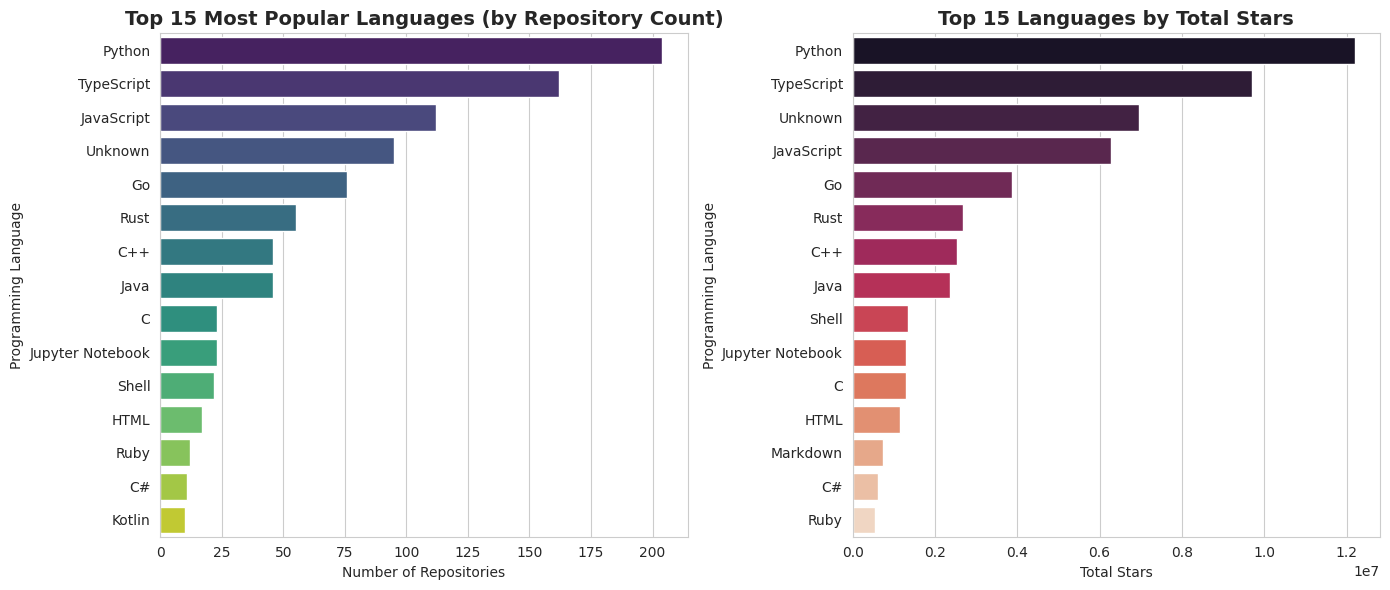

In [35]:
plt.figure(figsize=(14, 6))

# Count repos by primary language
language_counts = df_clean['primary_language'].value_counts().head(15)

plt.subplot(1, 2, 1)
sns.barplot(x=language_counts.values, y=language_counts.index, palette='viridis')
plt.title('Top 15 Most Popular Languages (by Repository Count)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Repositories')
plt.ylabel('Programming Language')

# Total stars by language
language_stars = df_clean.groupby('primary_language')['stars'].sum().sort_values(ascending=False).head(15)

plt.subplot(1, 2, 2)
sns.barplot(x=language_stars.values, y=language_stars.index, palette='rocket')
plt.title('Top 15 Languages by Total Stars', fontsize=14, fontweight='bold')
plt.xlabel('Total Stars')
plt.ylabel('Programming Language')

plt.tight_layout()
plt.savefig('popular_languages.png', dpi=300, bbox_inches='tight')
plt.show()

#### Language use by Domain

Original dataframe: 1000 rows
Exploded dataframe: 1243 rows

Sample domains: 0               Other
1               Other
2     Web Development
3               Other
4    Machine Learning
Name: domains, dtype: str


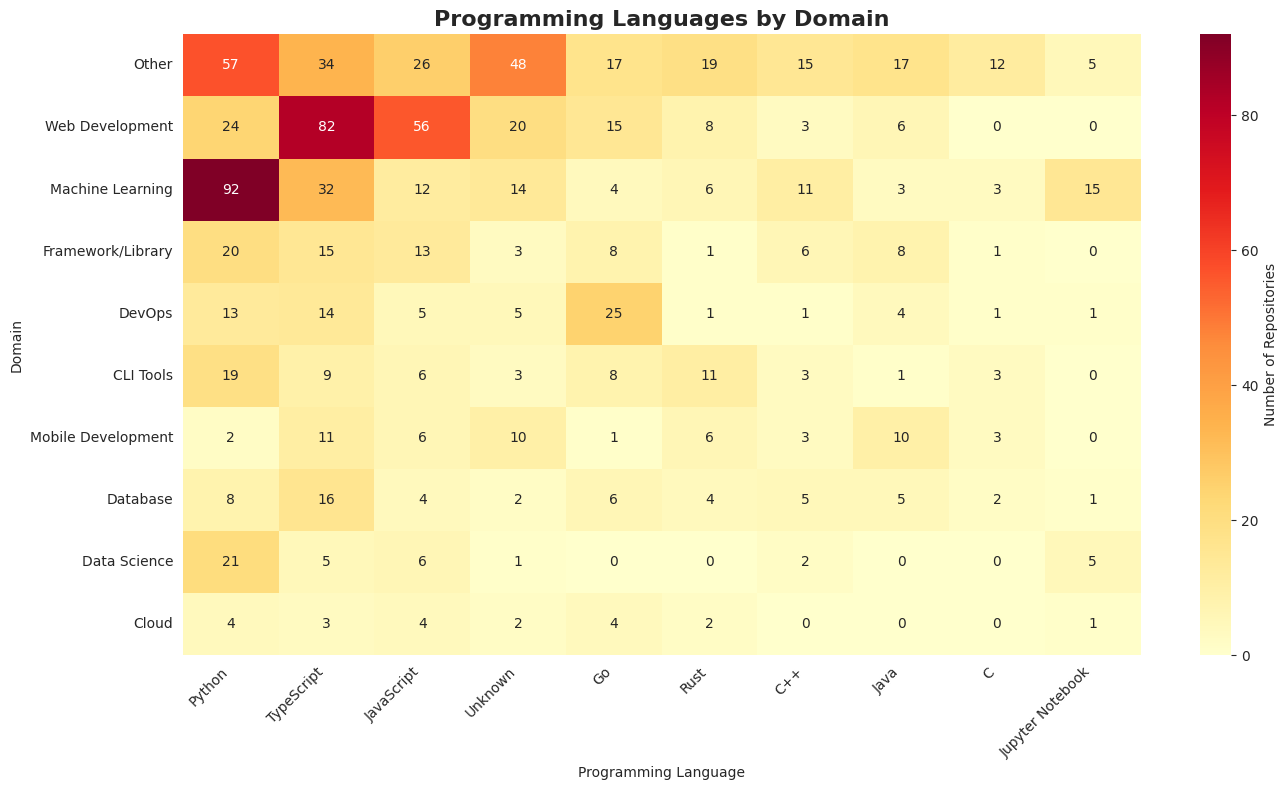

In [37]:
# Explode domains (since repos can have multiple domains)
# Make sure to reset index to avoid issues
df_exploded = df_clean.explode('domains').reset_index(drop=True)

# Check if explosion worked
print(f"Original dataframe: {len(df_clean)} rows")
print(f"Exploded dataframe: {len(df_exploded)} rows")
print(f"\nSample domains: {df_exploded['domains'].head()}")

# Create cross-tabulation
domain_language = pd.crosstab(df_exploded['domains'], df_exploded['primary_language'])

# Get top languages and domains
top_languages = df_clean['primary_language'].value_counts().head(10).index
top_domains = df_exploded['domains'].value_counts().head(10).index

# Filter to top items
domain_language_filtered = domain_language.loc[top_domains, top_languages]

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(domain_language_filtered, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Number of Repositories'})
plt.title('Programming Languages by Domain', fontsize=16, fontweight='bold')
plt.xlabel('Programming Language')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('language_by_domain.png', dpi=300, bbox_inches='tight')
plt.show()

#### Most Popular Repos

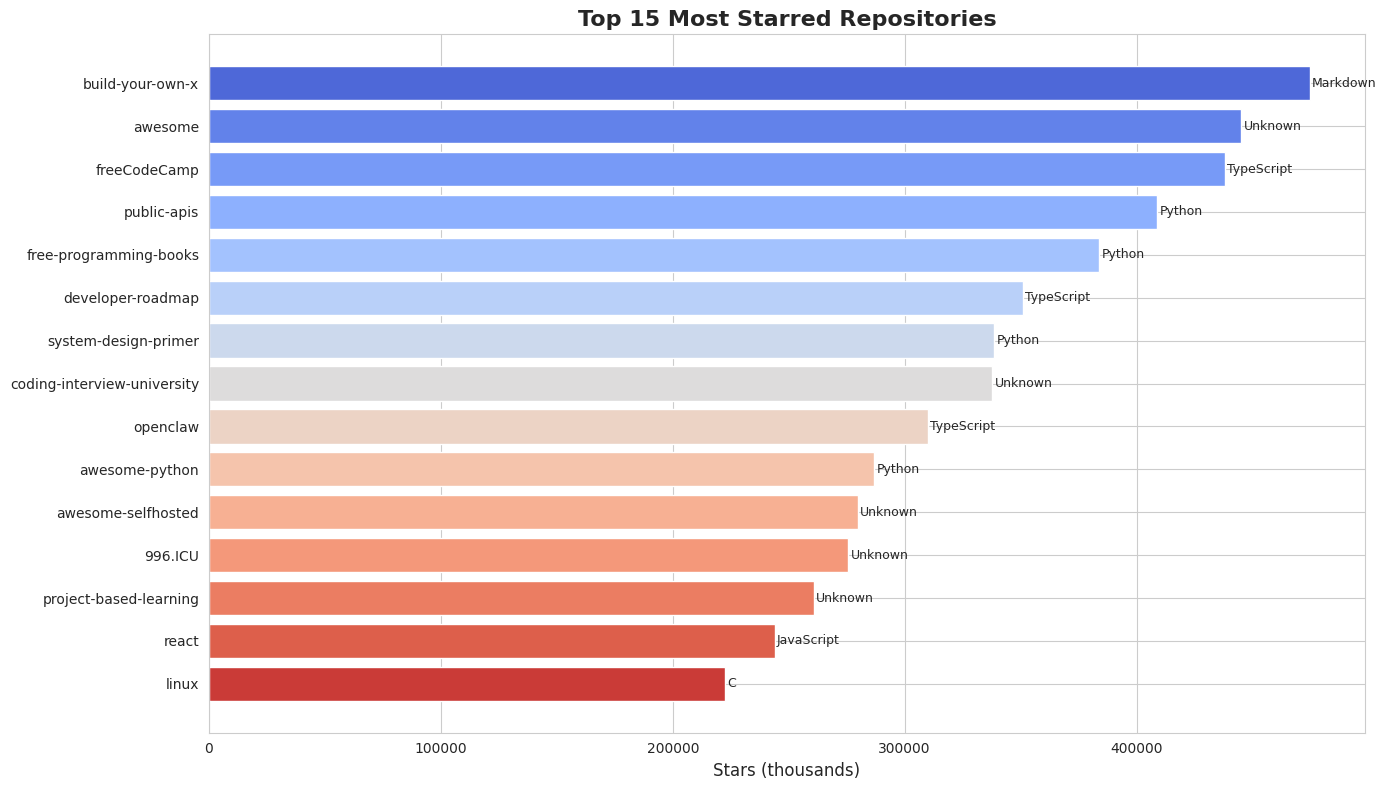


Top Repositories:
                       name primary_language  stars                              domains
           build-your-own-x         Markdown 474726                              [Other]
                    awesome          Unknown 445182                              [Other]
               freeCodeCamp       TypeScript 438078                    [Web Development]
                public-apis           Python 409004                              [Other]
     free-programming-books           Python 383945                   [Machine Learning]
          developer-roadmap       TypeScript 350829                              [Other]
       system-design-primer           Python 338701                    [Web Development]
coding-interview-university          Unknown 337785                              [Other]
                   openclaw       TypeScript 310143                   [Machine Learning]
             awesome-python           Python 286933                  [Framework/Library]
  

In [38]:
top_repos_df = df_clean.nlargest(15, 'stars')[['name', 'primary_language', 'stars', 'domains']]

plt.figure(figsize=(14, 8))
bars = plt.barh(top_repos_df['name'], top_repos_df['stars'], 
                color=sns.color_palette('coolwarm', len(top_repos_df)))
plt.xlabel('Stars (thousands)', fontsize=12)
plt.title('Top 15 Most Starred Repositories', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()

# Add language labels
for idx, (bar, lang) in enumerate(zip(bars, top_repos_df['primary_language'])):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, 
             f'{lang}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_repositories.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop Repositories:")
print(top_repos_df.to_string(index=False))

#### Rising Languages Analysis

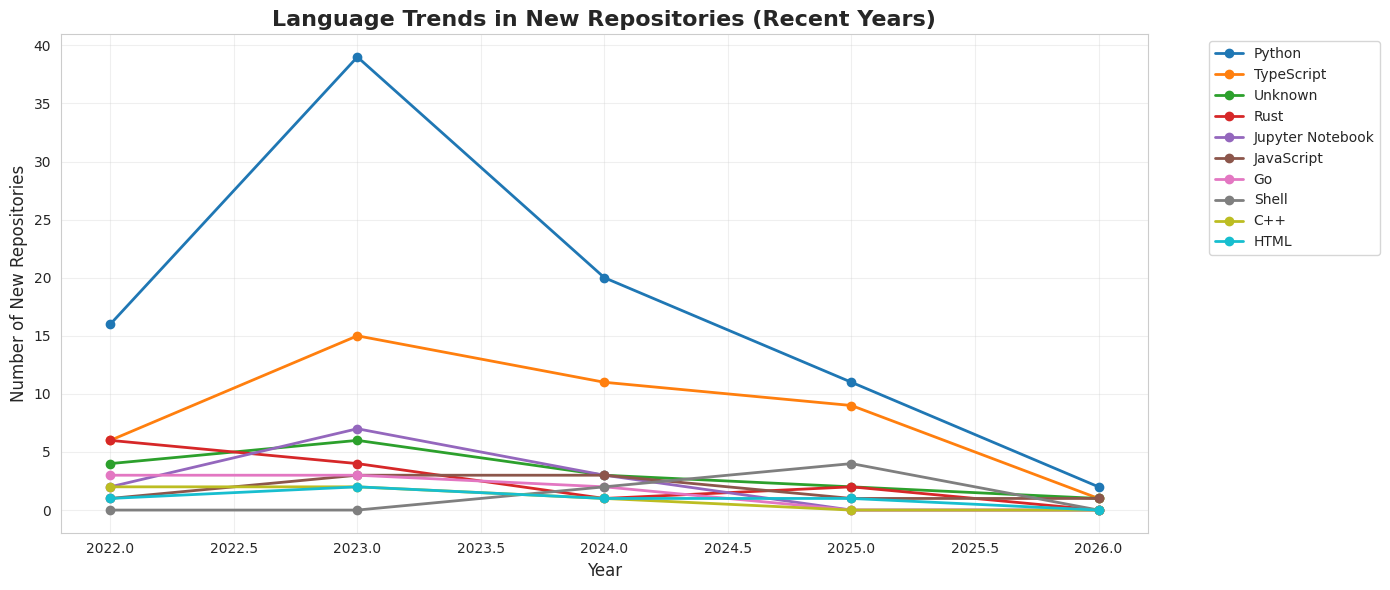

In [39]:
# Look at repos created in last 3 years and group by year
df_clean['year_created'] = df_clean['created_at'].dt.year
recent_years = df_clean[df_clean['year_created'] >= 2022]

# Count by language and year
language_by_year = recent_years.groupby(['year_created', 'primary_language']).size().unstack(fill_value=0)

# Get languages that appear in recent years
recent_languages = language_by_year.sum().nlargest(10).index
language_by_year_top = language_by_year[recent_languages]

# Plot trends
plt.figure(figsize=(14, 6))
for lang in recent_languages:
    plt.plot(language_by_year_top.index, language_by_year_top[lang], 
             marker='o', label=lang, linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of New Repositories', fontsize=12)
plt.title('Language Trends in New Repositories (Recent Years)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('language_trends.png', dpi=300, bbox_inches='tight')
plt.show()

#### Language Combinations

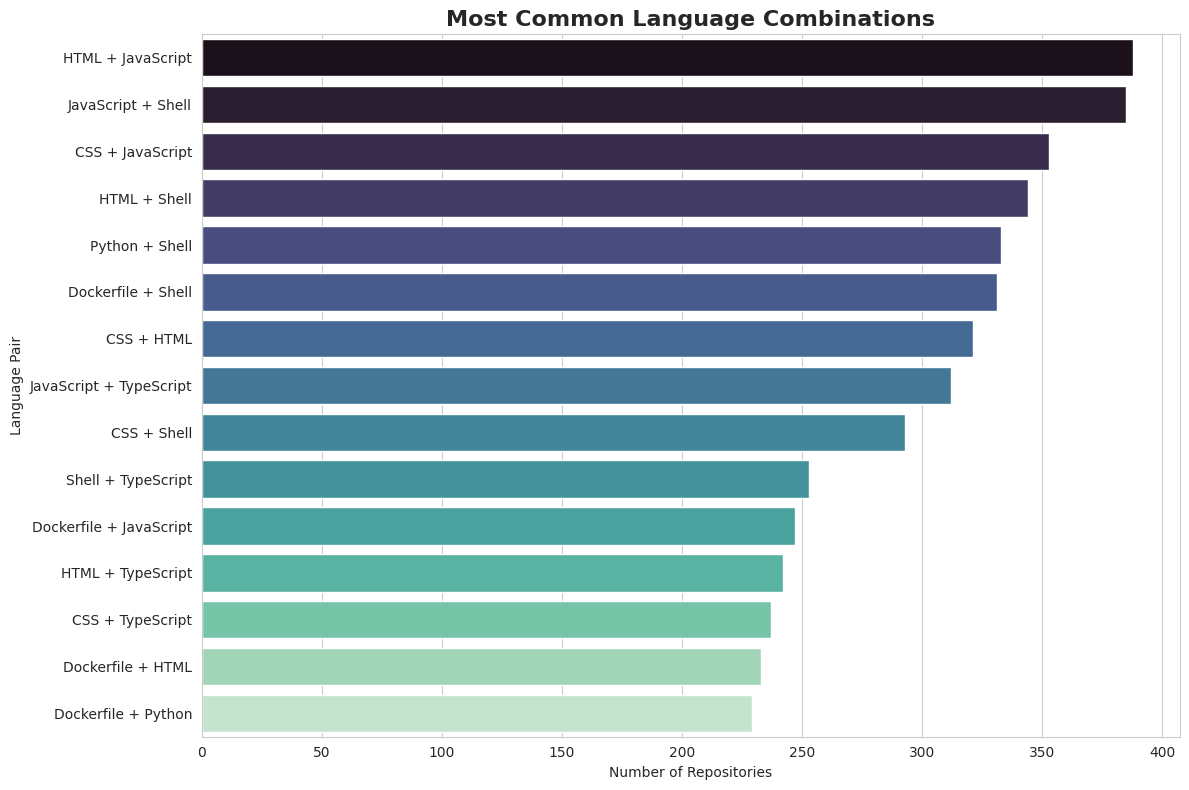

In [40]:
# Find which languages are commonly used together

def get_language_pairs(lang_dict):
    """Get pairs of languages used together"""
    if not lang_dict or len(lang_dict) < 2:
        return []
    
    languages = list(lang_dict.keys())
    pairs = []
    for i in range(len(languages)):
        for j in range(i+1, len(languages)):
            pairs.append(tuple(sorted([languages[i], languages[j]])))
    return pairs

all_pairs = []
for langs in df_clean['all_languages']:
    all_pairs.extend(get_language_pairs(langs))

pair_counts = Counter(all_pairs)
top_pairs = pd.DataFrame(pair_counts.most_common(15), 
                         columns=['Language Pair', 'Count'])
top_pairs['Pair'] = top_pairs['Language Pair'].apply(lambda x: f"{x[0]} + {x[1]}")

plt.figure(figsize=(12, 8))
sns.barplot(data=top_pairs, y='Pair', x='Count', palette='mako')
plt.title('Most Common Language Combinations', fontsize=16, fontweight='bold')
plt.xlabel('Number of Repositories')
plt.ylabel('Language Pair')
plt.tight_layout()
plt.savefig('language_combinations.png', dpi=300, bbox_inches='tight')
plt.show()

#### Repository Activity and Engagement

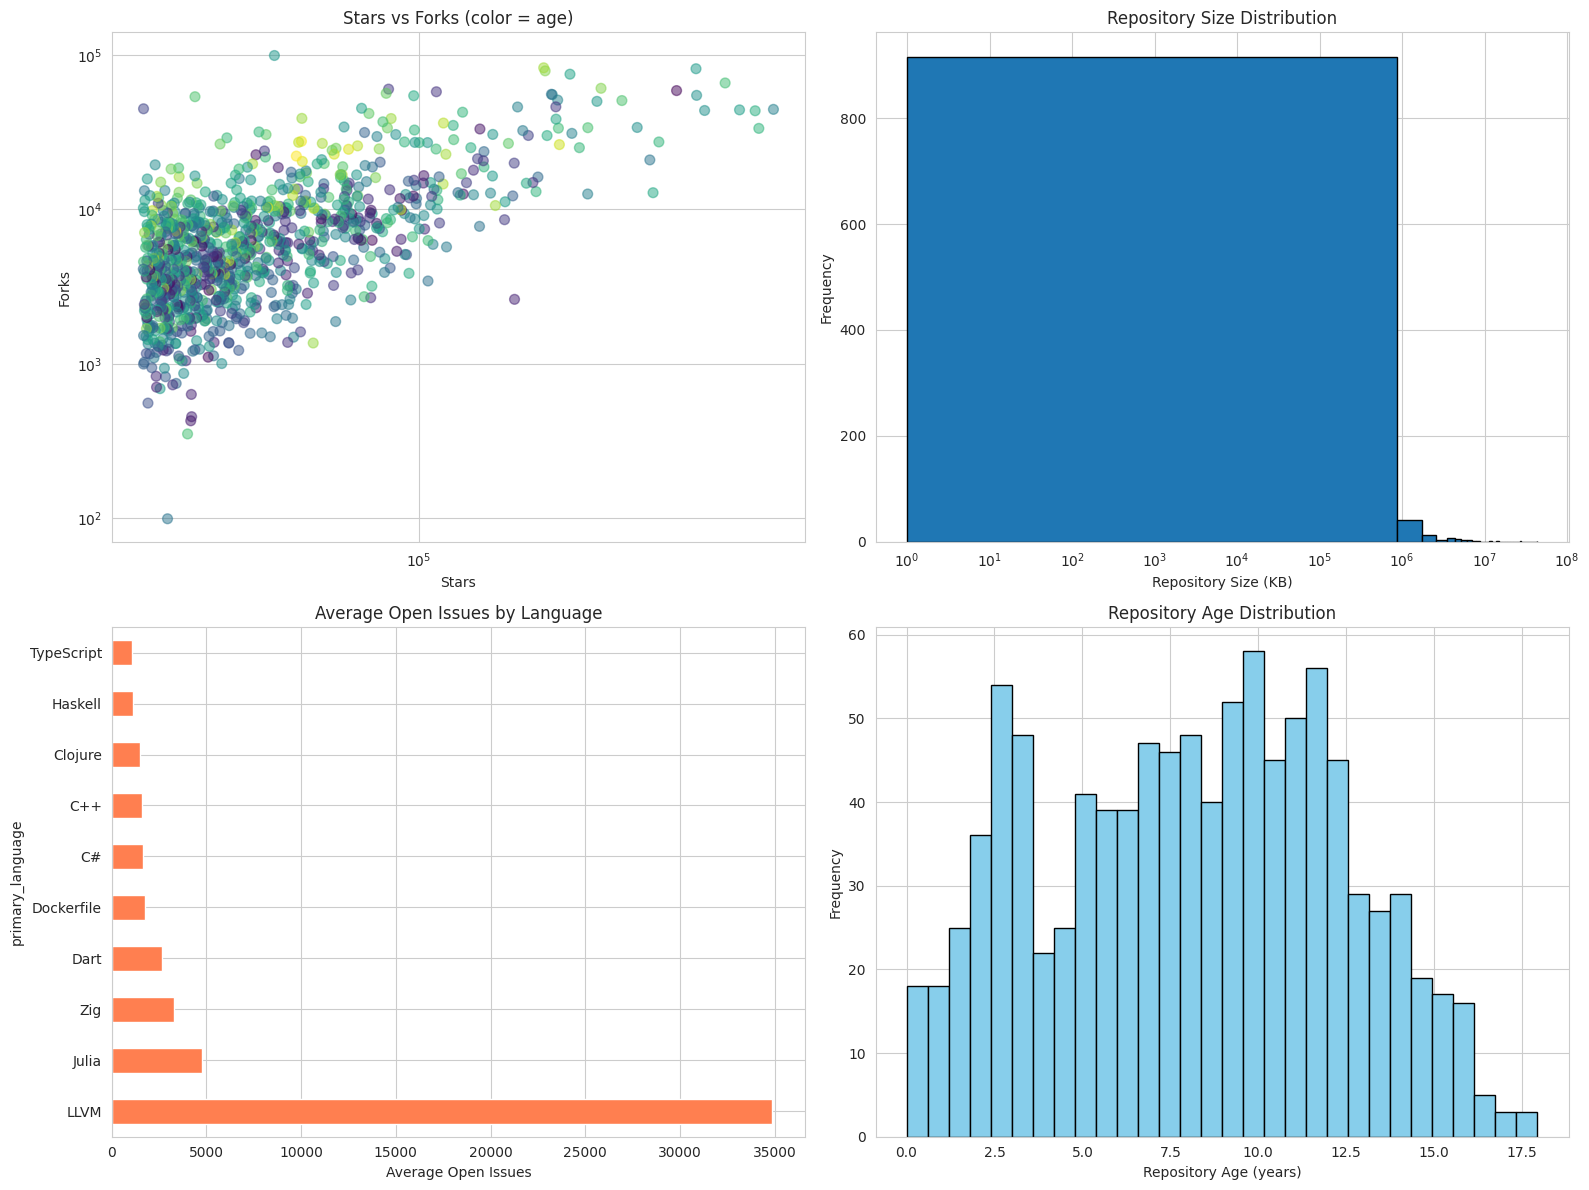

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Stars vs Forks
axes[0, 0].scatter(df_clean['stars'], df_clean['forks'], alpha=0.5, c=df_clean['age_days'], 
                   cmap='viridis', s=50)
axes[0, 0].set_xlabel('Stars')
axes[0, 0].set_ylabel('Forks')
axes[0, 0].set_title('Stars vs Forks (color = age)')
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')

# Repository Size Distribution
df_clean[df_clean['size'] > 0]['size'].hist(bins=50, ax=axes[0, 1], edgecolor='black')
axes[0, 1].set_xlabel('Repository Size (KB)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Repository Size Distribution')
axes[0, 1].set_xscale('log')

# Open Issues Distribution
top_lang_issues = df_clean.groupby('primary_language')['open_issues'].mean().nlargest(10)
top_lang_issues.plot(kind='barh', ax=axes[1, 0], color='coral')
axes[1, 0].set_xlabel('Average Open Issues')
axes[1, 0].set_title('Average Open Issues by Language')

# Repository Age Distribution
axes[1, 1].hist(df_clean['age_days'] / 365, bins=30, edgecolor='black', color='skyblue')
axes[1, 1].set_xlabel('Repository Age (years)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Repository Age Distribution')

plt.tight_layout()
plt.savefig('repository_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

#### Domain Distribution

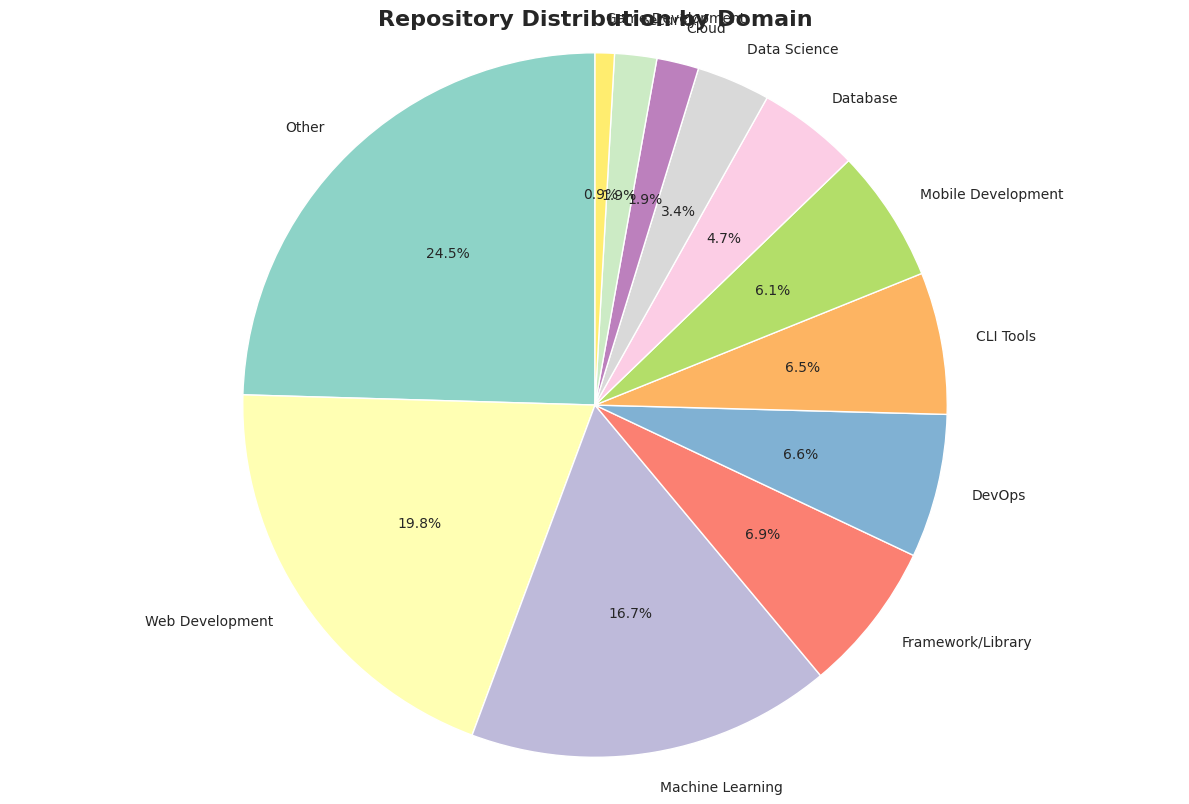

In [42]:
domain_counts = df_exploded['domains'].value_counts().head(12)

plt.figure(figsize=(12, 8))
plt.pie(domain_counts.values, labels=domain_counts.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('Set3', len(domain_counts)))
plt.title('Repository Distribution by Domain', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('domain_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### Summary Statistics

In [43]:
print("=" * 60)
print("GITHUB REPOSITORY ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nTotal Repositories Analyzed: {len(df_clean)}")
print(f"Date Range: {df_clean['created_at'].min().date()} to {df_clean['created_at'].max().date()}")
print(f"\nTotal Stars: {df_clean['stars'].sum():,}")
print(f"Total Forks: {df_clean['forks'].sum():,}")
print(f"Average Stars per Repo: {df_clean['stars'].mean():.0f}")

print("\n" + "-" * 60)
print("TOP 5 LANGUAGES")
print("-" * 60)
print(df_clean['primary_language'].value_counts().head())

print("\n" + "-" * 60)
print("TOP 5 DOMAINS")
print("-" * 60)
print(df_exploded['domains'].value_counts().head())

print("\n" + "-" * 60)
print("RISING STARS (Top 5 by growth rate)")
print("-" * 60)
for idx, row in rising_repos.head(5).iterrows():
    print(f"{row['name']}: {row['stars_per_day']:.1f} stars/day ({row['primary_language']})")

print("\n" + "-" * 60)
print("MOST ACTIVE REPOSITORIES (by recent updates)")
print("-" * 60)
most_active = df_clean.nsmallest(5, 'activity_score')[['name', 'primary_language', 'updated_at']]
for idx, row in most_active.iterrows():
    print(f"{row['name']} ({row['primary_language']}): Last updated {row['updated_at'].date()}")

GITHUB REPOSITORY ANALYSIS SUMMARY

Total Repositories Analyzed: 1000
Date Range: 2008-04-11 to 2026-03-06

Total Stars: 58,326,751
Total Forks: 8,996,476
Average Stars per Repo: 58327

------------------------------------------------------------
TOP 5 LANGUAGES
------------------------------------------------------------
primary_language
Python        204
TypeScript    162
JavaScript    112
Unknown        95
Go             76
Name: count, dtype: int64

------------------------------------------------------------
TOP 5 DOMAINS
------------------------------------------------------------
domains
Other                305
Web Development      246
Machine Learning     208
Framework/Library     86
DevOps                82
Name: count, dtype: int64

------------------------------------------------------------
RISING STARS (Top 5 by growth rate)
------------------------------------------------------------
autoresearch: 4376.1 stars/day (Python)
openclaw: 2819.5 stars/day (TypeScript)
everythi

#### Correlation Analysis

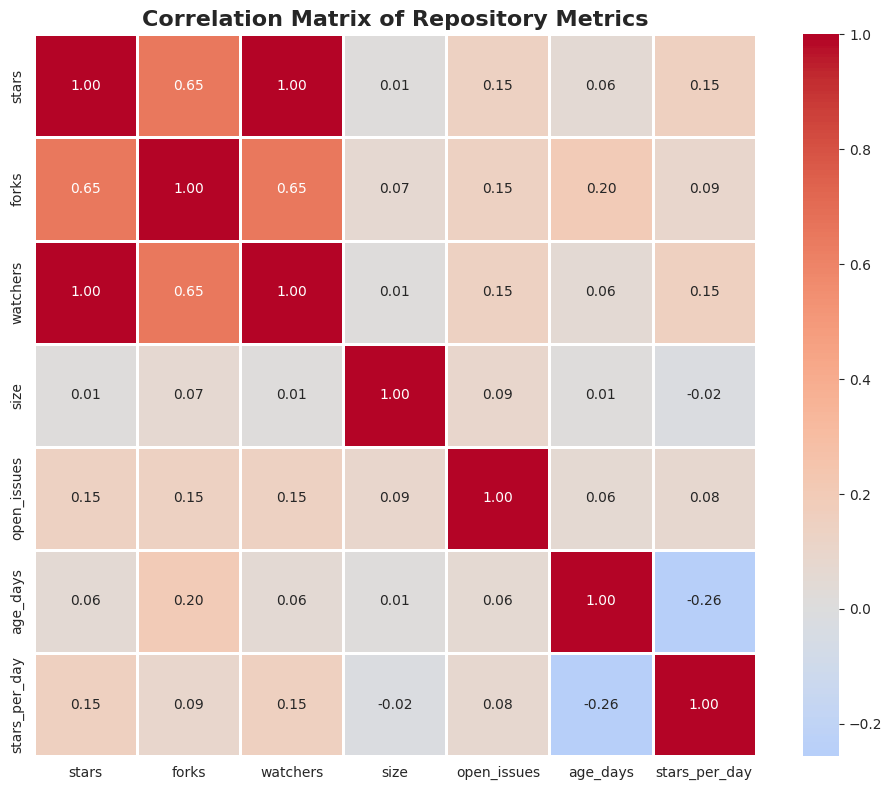

In [44]:
# Analyze correlations between metrics

numeric_cols = ['stars', 'forks', 'watchers', 'size', 'open_issues', 'age_days', 'stars_per_day']
correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Repository Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

#### License Analysis

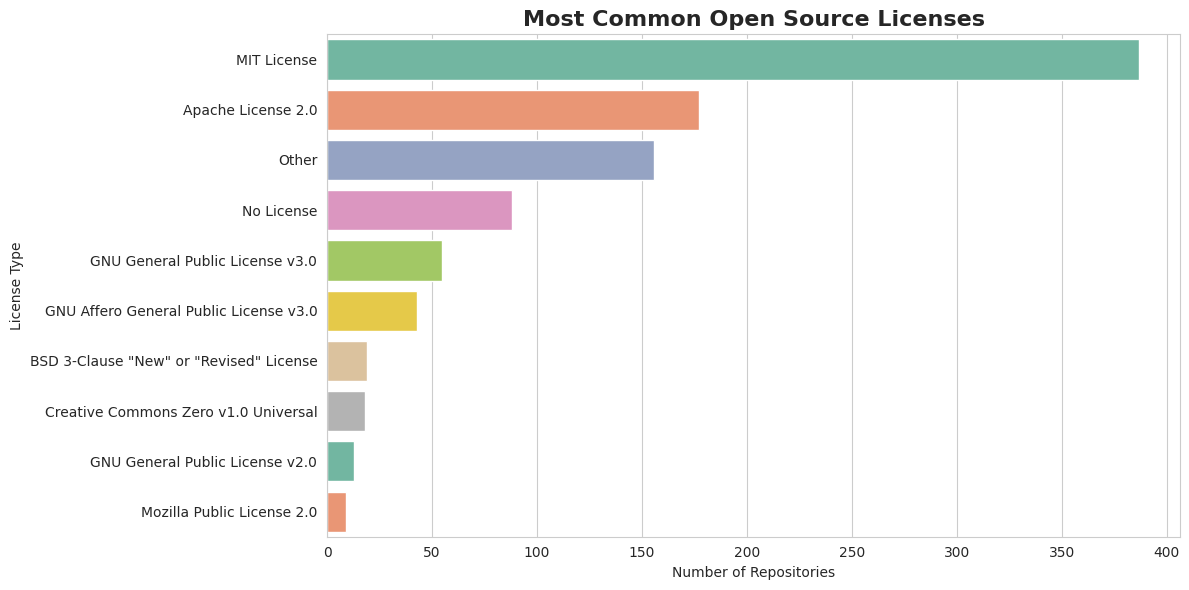

In [45]:
license_counts = df_clean['license'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=license_counts.values, y=license_counts.index, palette='Set2')
plt.title('Most Common Open Source Licenses', fontsize=16, fontweight='bold')
plt.xlabel('Number of Repositories')
plt.ylabel('License Type')
plt.tight_layout()
plt.savefig('license_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### Exporting Final Results

In [46]:
# Create summary DataFrames for different analyses

# Language summary
language_summary = df_clean.groupby('primary_language').agg({
    'stars': ['count', 'sum', 'mean'],
    'forks': 'sum',
    'stars_per_day': 'mean'
}).round(2)
language_summary.columns = ['repo_count', 'total_stars', 'avg_stars', 'total_forks', 'avg_growth_rate']
language_summary = language_summary.sort_values('total_stars', ascending=False)

# Domain summary
domain_summary = df_exploded.groupby('domains').agg({
    'stars': ['count', 'mean'],
    'primary_language': lambda x: x.value_counts().index[0]  # Most common language
}).round(2)
domain_summary.columns = ['repo_count', 'avg_stars', 'dominant_language']

# Export to CSV
language_summary.to_csv('language_summary.csv')
domain_summary.to_csv('domain_summary.csv')
rising_repos.to_csv('rising_repositories.csv', index=False)

print("Analysis complete! Files exported:")
print("- language_summary.csv")
print("- domain_summary.csv")
print("- rising_repositories.csv")
print("- github_repos_raw.csv")

Analysis complete! Files exported:
- language_summary.csv
- domain_summary.csv
- rising_repositories.csv
- github_repos_raw.csv
